# Climate Futures classification

This notebook executes methods to classify a climate scenario data ensemble into the National Park Service's *Climate Futures framework*.

`src` contain all the function needed:
- `configs.py` defined global variables
- `dataLoader.py` is a class with methods to load various data sets. Sofar ISIMIP 3b, and CalAdapt (CMIP6 downscaled with LOCA2-hyrbrid) have been implemented. If you are interested in using a different data source, you will need to add a method to the `dataLoader()` class
- `climateFutures.py` contains all the functions needed to classify scenarios. If your `dataLoader()` method is written correctly, it should be able to work with any newly added dataset. 

For information on the *Climate Futures* methodology can be found here: https://www.nps.gov/subjects/climatechange/climatefutures.htm

In [1]:
import pandas as pd
import numpy as np

import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from plotnine import (ggplot, aes, geom_point, geom_vline, geom_hline,
                      geom_rect, scale_fill_manual, scale_color_manual,
                      scale_shape_manual, labs, theme_bw, theme)
from src import dataLoader 
from src import climateFutures 
from src import config

## CalAdapt

This illustrated functionality for CalAdapt, the main data set we are using

### 1. Load data

Load data for Joshua Tree National Park and plot ensemble to verify it worked.

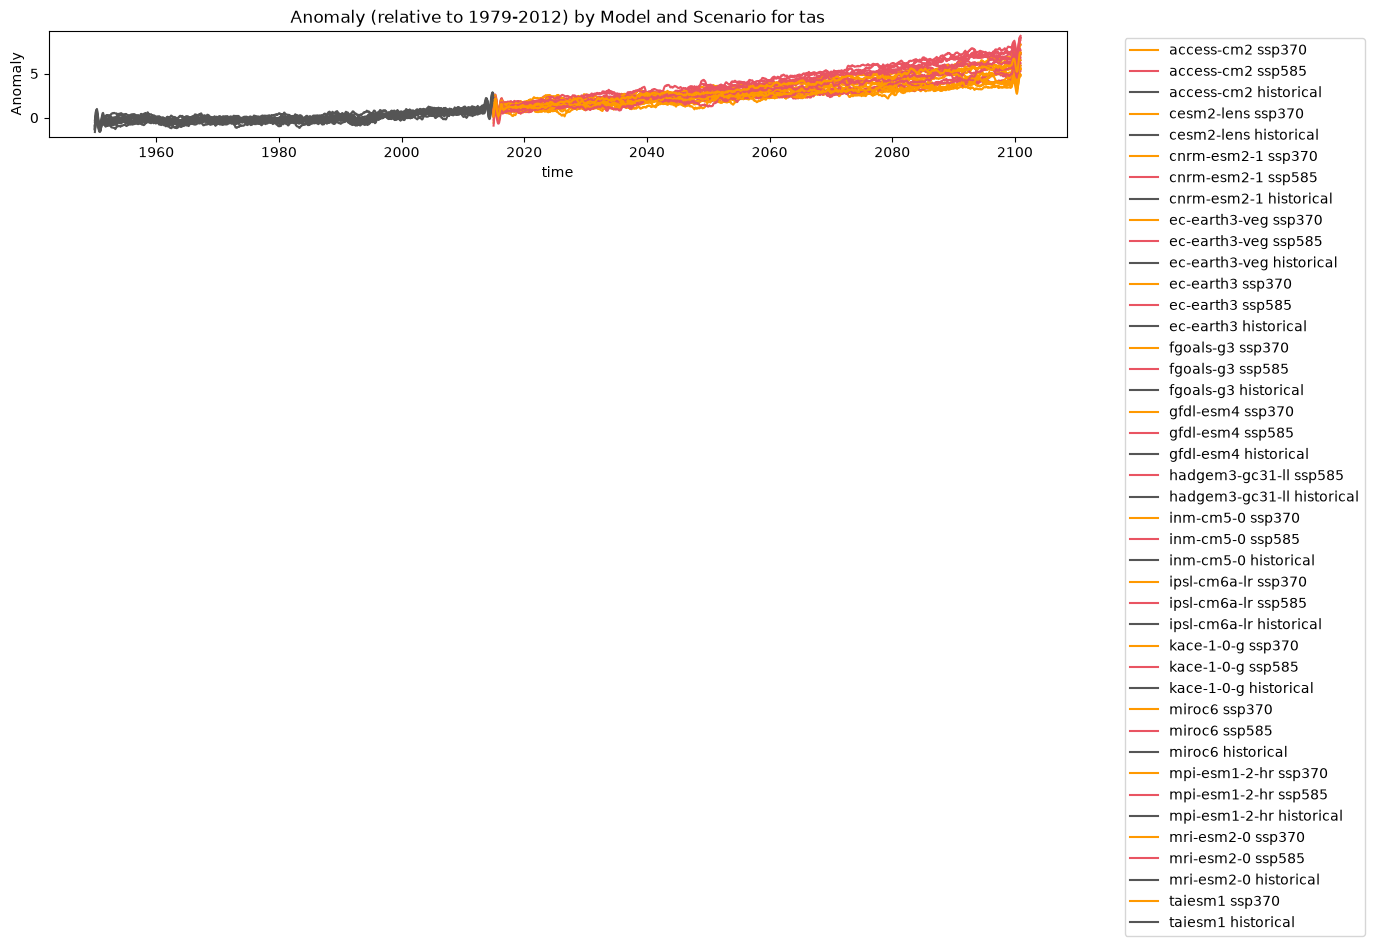

In [2]:
loader = dataLoader.DataLoader()

cf_ca = climateFutures.ClimateFutures(
    scenarios=config.SCENARIOS,
    models=config.MODELS_CALADAPT,
    park=config.PARKS[0],
    baseline_period=config.BASELINE_PERIOD,
    load_fn=loader.load_caladapt
)

cf_ca.plot_ensemble(variable='tas')

### 2. Classify

Classify ensemble into the different climate futures and plot them

In [ ]:
results = cf_ca.classify()
results.to_csv(f'{config.OUTPUT}/climate_futures_jotr.csv', index=False)

Skipped 3 missing model/scenario combinations: [('cesm2-lens_r1i1p1f1', 'ssp585'), ('hadgem3-gc31-ll_r1i1p1f3', 'ssp370'), ('taiesm1_r1i1p1f1', 'ssp585')]
           tas        pr
0.25  2.305863 -0.000018
0.50  2.703903 -0.000011
0.75  3.029262  0.000005


### 3. Plot time series for the re-classified scenarios

Skipped 3 missing model/scenario combinations: [('cesm2-lens_r1i1p1f1', 'ssp585'), ('hadgem3-gc31-ll_r1i1p1f3', 'ssp370'), ('taiesm1_r1i1p1f1', 'ssp585')]


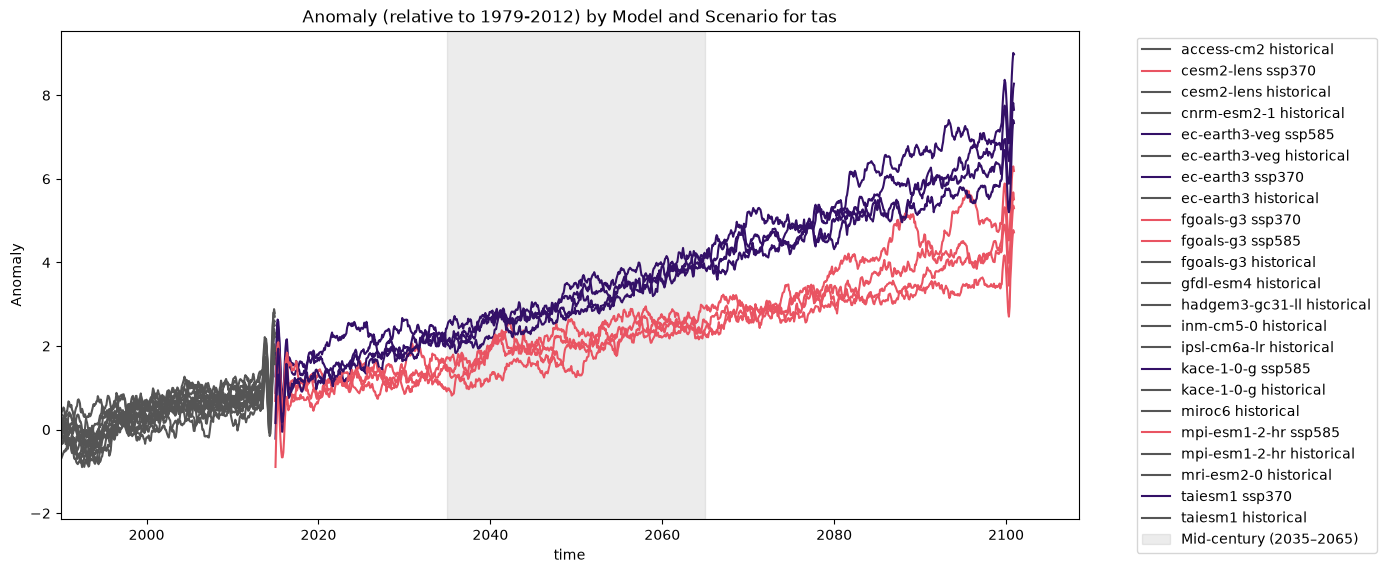

Skipped 3 missing model/scenario combinations: [('cesm2-lens_r1i1p1f1', 'ssp585'), ('hadgem3-gc31-ll_r1i1p1f3', 'ssp370'), ('taiesm1_r1i1p1f1', 'ssp585')]


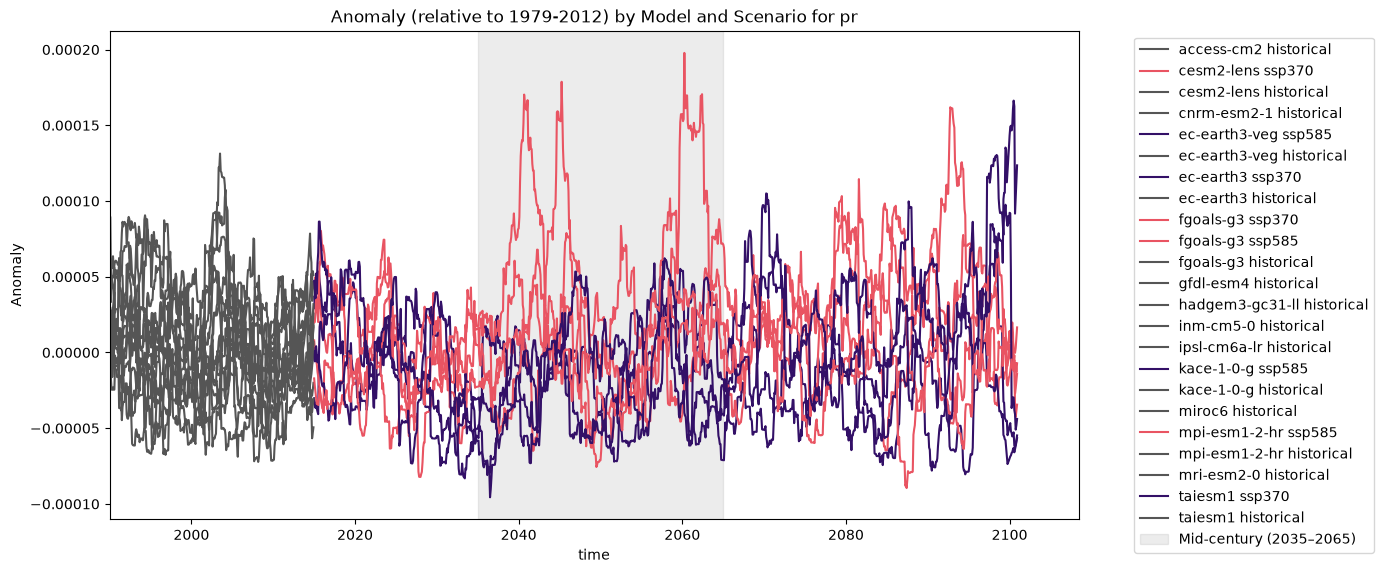

In [9]:
cf_ca.plot_climate_futures('tas', futures=['warm-wet', 'hot-dry'])
cf_ca.plot_climate_futures('pr', futures=['warm-wet', 'hot-dry'])